# 🌐 第 70 课 · AI 编译器发展趋势:站在浪潮之巅

> torch.compile 成熟 · MLIR 生态 · 异构 · LLM 推理专用编译 · 论文导读与学习路线

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 梳理 AI 编译器的五大趋势:torch.compile 成熟、MLIR 生态、异构、LLM 推理专用编译、可微分/通用
- 用时间线看懂 AI 编译器的发展脉络(Halide → TVM → Ansor → MLIR → torch.compile)
- 导读经典论文:Halide / TVM / Ansor / TensorIR,知道每篇贡献了什么
- 理解 LLM 推理为什么催生专用编译(融合、CUDA Graph、KV Cache 内存)
- 用 matplotlib / seaborn 画时间线、趋势矩阵与学习路线图
- 为读者梳理第 10 章之后的可继续学习路线

## 📑 本课目录

1. **五大趋势总览** — 成熟 / 生态 / 异构 / LLM 专用 / 未来
2. **发展时间线** — 从 Halide 到 torch.compile 的二十年
3. **LLM 推理专用编译** — 为什么 LLM 是编译器的下一个主战场
4. **论文导读** — Halide / TVM / Ansor / TensorIR 各贡献了什么
5. **学习路线图** — 第 10 章之后的进阶之路

## 🔗 参考资料

- [Halide 论文](https://people.csail.mit.edu/nickolai/papers/ragan-kelley-halide.pdf)
- [TVM 论文](https://arxiv.org/abs/1802.04799)
- [Ansor 论文](https://arxiv.org/abs/2006.06762)
- [MLIR 论文](https://arxiv.org/abs/2002.11054)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 五大趋势总览 🧭

站在 2026 年回头看,AI 编译器正沿着五条主线狂奔:

1. **torch.compile 走向成熟**:PyTorch 把『编译』变成默认体验,Dynamo + Inductor 让任何模型
   一键获得融合与加速;
2. **MLIR 成为基建**:以方言 + pass 管线的思想统一了 XLA / TVM / Triton 的底层,跨框架互操作成为现实;
3. **异构加速**:CPU / GPU / NPU / TPU / 专用 ASIC 百花齐放,编译器承担『一次编写、多端适配』;
4. **LLM 推理专用编译**:融合、CUDA Graph、KV Cache 内存、PagedAttention —— 编译器被推上推理性能主战场;
5. **可微分与可学习调度**:把『搜索』与『学习』引入调度,自动调优从枚举走向学习(如 Learning to Schedule)。

下面先用时间线把这几十年串起来。

📈 时间线:从『算法/调度分离』到『LLM 专用编译』,编译器一直是性能的引擎。

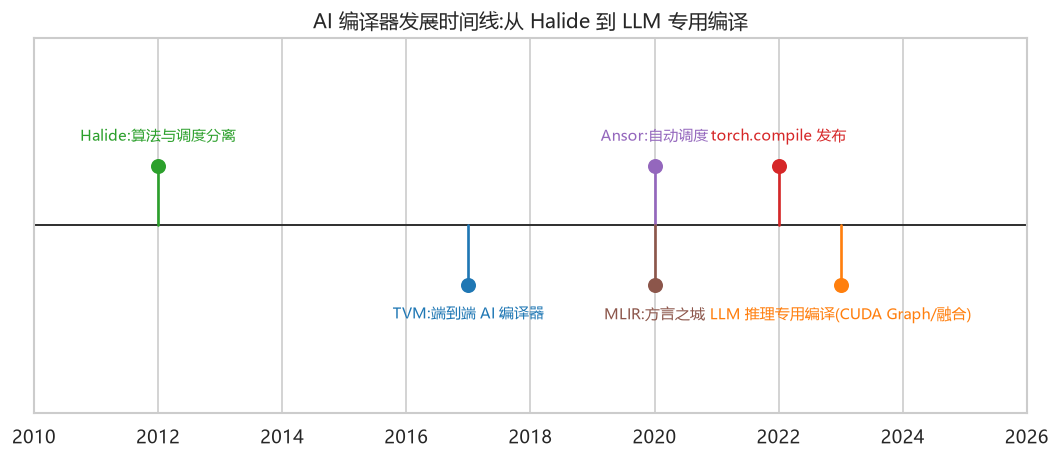

In [2]:
import matplotlib.pyplot as plt
events = [
    (2012, "Halide:算法与调度分离", "#2ca02c"),
    (2017, "TVM:端到端 AI 编译器", "#1f77b4"),
    (2020, "Ansor:自动调度", "#9467bd"),
    (2020, "MLIR:方言之城", "#8c564b"),
    (2022, "torch.compile 发布", "#d62728"),
    (2023, "LLM 推理专用编译(CUDA Graph/融合)", "#ff7f0e"),
]
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(0, color="#333", lw=1.2)
for i, (year, label, color) in enumerate(events):
    y = 1 if i % 2 == 0 else -1
    ax.plot([year, year], [0, y * 0.7], color=color, lw=1.6)
    ax.plot(year, y * 0.7, "o", color=color, ms=8)
    ax.text(year, y * 0.95, f"{label}", ha="center", va="bottom" if y > 0 else "top", fontsize=9, color=color)
ax.set_xlim(2010, 2026); ax.set_ylim(-2.2, 2.2); ax.set_yticks([])
ax.set_title("AI 编译器发展时间线:从 Halide 到 LLM 专用编译")
plt.tight_layout()

## 2️⃣ 五大趋势逐一看 🔎

**① torch.compile 成熟**。PyTorch 把编译变成默认能力:Dynamo 追踪任意 Python,Inductor 生成
Triton/C++ kernel。本书 61-67 课就是用它在真机上手把手验证『图优化 → 融合 → 代码生成』。
它的意义在于:**把『编译』从少数专家的事,变成每个深度学习工程师的日常**。

**② MLIR 生态**。Google 的 MLIR 用『方言 + pass 管线』把不同抽象层次统一进一个编译器,
XLA(TorchMLIR)、TVM(TensorIR 对齐)、Triton(TTGIR)都借鉴了它的思想。跨框架、跨硬件
共用一套编译基建,是 MLIR 的长期愿景。

**③ 异构加速**。端侧 NPU、数据中心 GPU/TPU、专用 ASIC 层出不穷。每类硬件的『最佳 kernel』不同,
编译器承担『一次编写、多端适配』:写一份高层描述,针对不同后端生成不同代码 —— 这正是
第 68 课『调度』与第 65 课『自动调优』要解决的多端适配难题。

**④ LLM 推理专用编译**。LLM 推理(尤其 decode)张量小、算子碎、访存密集,催生了大量编译优化:
逐元素融合(67 课)、CUDA Graph 减少启动、KV Cache 内存复用(63 课)、PagedAttention、
vLLM 的 piecewise 编译 —— 编译器直接决定了推理的吞吐与延迟,成为大模型服务的主战场。

**⑤ 可学习调度**。Ansor 之后,『用机器学习/强化学习学出好的调度策略』成为前沿,成本模型本身
也是可学习的。调优从『枚举』走向『预测 + 搜索』。

📊 趋势矩阵:torch.compile 与 LLM 推理专用编译与你当下最相关 —— 本书第 10 章正好都覆盖了。

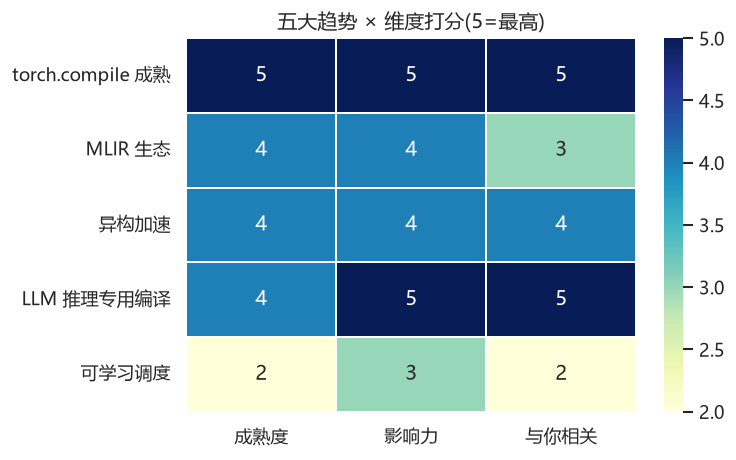

In [3]:
# 趋势矩阵:五大趋势 × 成熟度/影响力
import seaborn as sns
trends = pd.DataFrame({
    "成熟度": [5, 4, 4, 4, 2],
    "影响力": [5, 4, 4, 5, 3],
    "与你相关": [5, 3, 4, 5, 2],
}, index=["torch.compile 成熟", "MLIR 生态", "异构加速", "LLM 推理专用编译", "可学习调度"])
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(trends, annot=True, fmt="d", cmap="YlGnBu", linewidths=1, linecolor="white", ax=ax)
ax.set_title("五大趋势 × 维度打分(5=最高)")
plt.tight_layout()

## 3️⃣ 论文导读:每一篇贡献了什么 📚

读论文是深入编译器的最佳路径。四篇里程碑各解决一个问题:

| 论文 | 年份 | 核心贡献 | 本书对应 |
|---|---|---|---|
| **Halide** | 2012 | 首次把『算法』与『调度』分离,一行调度换性能 | 68 课(调度) |
| **TVM** | 2017 | 端到端 AI 编译器:前端→IR→自动调优→多后端 | 61/65 课(全景/调优) |
| **Ansor** | 2020 | 自动调度:在搜索空间里高效找最优 tile/并行 | 65 课(自动调优) |
| **TensorIR**(TVM 后篇) | 2022 | 以 MLIR 风格重写调度 IR,对齐 MLIR 生态 | 64 课(IR/方言) |

读的时候抓住主线:**先有『分离』(Halide)→ 再有『端到端』(TVM)→ 再有『自动搜』(Ansor)→
最后『统一 IR』(TensorIR/MLIR)**。这条主线正是第 10 章 61-70 课的浓缩。

📊 泡泡图:四篇论文的年代与影响力(引用量仅供直观示意) —— 越新越细,方向越清晰。

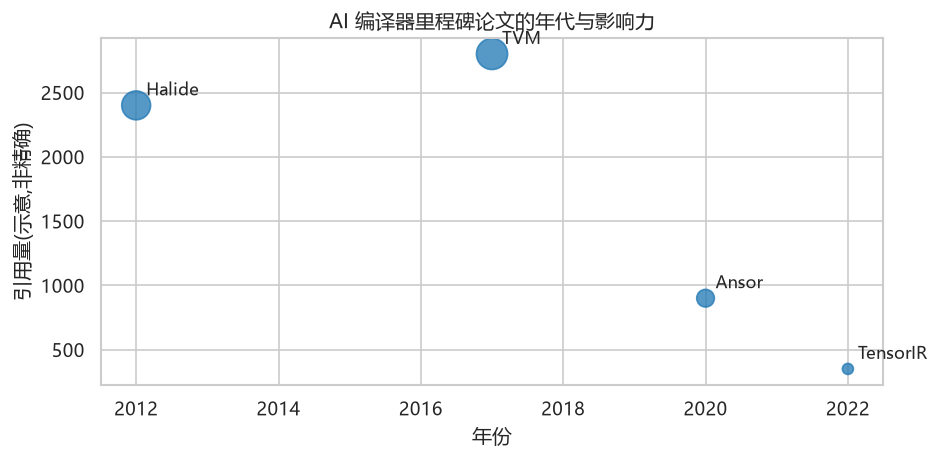

In [4]:
# 论文年代 + 引用量示意(真实量级,仅供直观)
papers = ["Halide", "TVM", "Ansor", "TensorIR"]
years = [2012, 2017, 2020, 2022]
cites = [2400, 2800, 900, 350]     # 示意量级,反映影响力
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(years, cites, s=[c / 8 for c in cites], color="#1f77b4", alpha=0.75)
for x, y, lab in zip(years, cites, papers):
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=10)
ax.set_xlabel("年份"); ax.set_ylabel("引用量(示意,非精确)")
ax.set_title("AI 编译器里程碑论文的年代与影响力")
plt.tight_layout()

## 4️⃣ 学习路线图 🗺️

学完第 10 章,想继续深入,可按这条路线走:

1. **吃透 PyTorch 编译栈**:读 Dynamo / Inductor 源码,用 `torch._inductor.config` 的各种开关
   观察编译行为(66/67 课已入门);
2. **学一门 DSL**:用 Triton 写 kernel 并亲手做自动调优(65/69 课已体验);
3. **啃 MLIR**:装 MLIR / 用 Triton 的 TTGIR 做实验(64 课已看到 TTGIR),再读 TensorIR;
4. **读论文**:按上表顺序读 Halide → TVM → Ansor,边读边复现;
5. **落到 LLM 推理**:研究 vLLM 的编译模式、CUDA Graph 与 KV Cache 内存优化(结合 63/67 课)。

下面把这条路画成图:

🎨 学习路线图:循序渐进,每一步都建立在前面课程打下的概念之上。

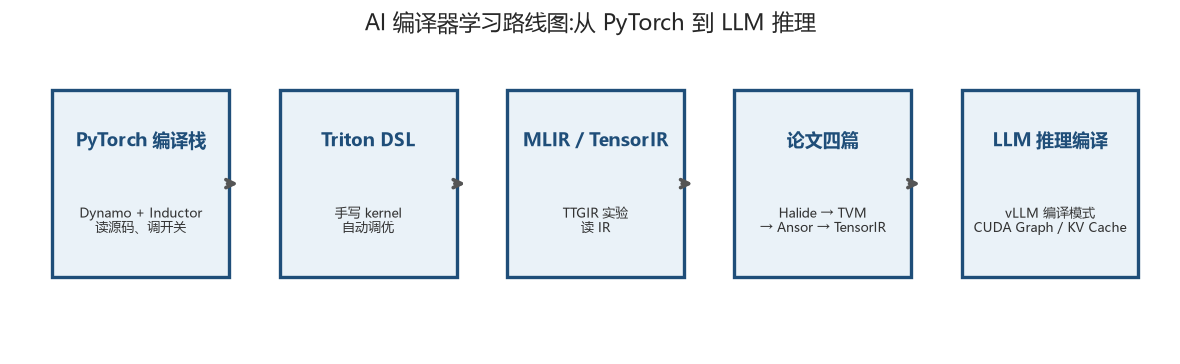

In [5]:
steps = [
    ("PyTorch 编译栈", "Dynamo + Inductor\n读源码、调开关"),
    ("Triton DSL", "手写 kernel\n自动调优"),
    ("MLIR / TensorIR", "TTGIR 实验\n读 IR"),
    ("论文四篇", "Halide → TVM\n→ Ansor → TensorIR"),
    ("LLM 推理编译", "vLLM 编译模式\nCUDA Graph / KV Cache"),
]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
x = 0.4; bw, bh = 1.75, 1.5
for i, (t, sub) in enumerate(steps):
    ax.add_patch(plt.Rectangle((x, 0.6), bw, bh, facecolor="#eaf2f8", edgecolor="#1f4e79", lw=2))
    ax.text(x + bw/2, 0.6 + bh*0.7, t, ha="center", fontsize=11, fontweight="bold", color="#1f4e79")
    ax.text(x + bw/2, 0.6 + bh*0.3, sub, ha="center", va="center", fontsize=8, color="#333")
    if i < len(steps)-1:
        ax.annotate("", xy=(x+bw+0.12, 1.35), xytext=(x+bw-0.05, 1.35), arrowprops=dict(arrowstyle="->", lw=2.2, color="#555"))
    x += bw + 0.5
ax.set_xlim(0, x-0.2); ax.set_ylim(0, 2.5)
ax.set_title("AI 编译器学习路线图:从 PyTorch 到 LLM 推理", fontsize=13)
plt.tight_layout()

## 5️⃣ 全书收尾 🎉

到这里,《VLLM_learn: 图解 vLLM 推理引擎》第 10 章「AI 编译器原理」就讲完了。我们把视角从
"用框架写模型"一路拉到了"编译器如何让模型跑得更快":全景(61)→ 图优化(62)→ 内存(63)→
IR(64)→ 自动调优(65)→ 代码生成(66)→ 融合(67)→ 调度(68)→ 库与编译器(69)→ 趋势(70)。

AI 编译器不是"锦上添花",而是大模型推理性能的核心引擎。愿你带着这份『编译器思维』,去看懂
vLLM 的每一处优化、读懂每一篇论文,在浪潮之巅继续前行。🌊

## ✅ 本课小结

- 五大趋势:torch.compile 成熟、MLIR 生态、异构加速、LLM 推理专用编译、可学习调度
- 时间线:Halide(分离)→ TVM(端到端)→ Ansor(自动调度)→ TensorIR/MLIR(统一 IR)→ torch.compile
- LLM 推理是编译器下一个主战场:融合、CUDA Graph、KV Cache 内存、PagedAttention 全是编译优化
- 论文导读:Halide(算法/调度分离)、TVM(端到端)、Ansor(自动调度)、TensorIR(统一 IR)
- 学习路线:吃透 PyTorch 编译栈 → Triton → MLIR → 读论文 → 落到 LLM 推理

## ✍️ 动手练习

1. 把第 61-70 课的标题画成一张知识地图,标注每课之间的依赖关系(建议:61→64→66→67→69 一条主线)
2. 选一篇论文(Halide / TVM / Ansor)通读,写 500 字笔记,找出它解决了本书哪一课的哪个问题
3. 用 torch.compile 的 max-autotune 在更大模型上跑一次,记录编译时间与加速比,体会『编译 vs 运行』的权衡
4. 为『LLM 推理专用编译』写一段展望:未来 3 年编译器会在哪些环节继续突破?

## 🔗 延伸阅读

- [Halide 论文](https://people.csail.mit.edu/nickolai/papers/ragan-kelley-halide.pdf)
- [TVM 论文](https://arxiv.org/abs/1802.04799)
- [Ansor 论文](https://arxiv.org/abs/2006.06762)
- [MLIR 论文](https://arxiv.org/abs/2002.11054)
- [vLLM 官方文档](https://docs.vllm.ai)

---
> 🎉 恭喜完成本课!下一课见!